In [154]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Implementation of MCP Neuron for AND and OR Function.

Limitations of MCP Neurons:

* Fixed, hand-crafted threshold (no learning)
* Binary inputs/outputs only
* Cannot solve non-linearly separable problems (e.g., XOR with a single neuron)
* No learning mechanism
* All inputs have equal weight
* Inhibitory inputs act as absolute vetoes

In [155]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  ### YOUR CODE HERE ###
  state_neuron = []

  for i in range(len(X1)):
    s = X1[i] + X2[i]
    if s >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  # Perform an element wise addition of two input arrays stored in a new array(list):
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

  return state_neuron

In [156]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [157]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    weighted_sum = [X1[i] + X2[i] for i in range(len(X1))]

    # Create output list
    state_neuron = []

    # Append 1 if sum is >= Threshold, else append 0
    for s in weighted_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

    return state_neuron


In [158]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


 XOR with MCP Neurons:\
The XOR problem reveals the fundamental limitation of a single MCP neuron — it can only represent linearly separable functions. XOR requires at least 2 layers of neurons, which is exactly what motivated Rosenblatt's Perceptron and eventually multi-layer neural networks.

In [159]:
def MCP_XOR(X1, X2):
    """
    Solves XOR using a combination of MCP AND and OR neurons.
    XOR(X1, X2) = AND( OR(X1, X2), NOT(AND(X1, X2)) )
    """
    assert len(X1) == len(X2)

    or_result  = MCP_Neurons_OR(X1, X2, T=1)
    and_result = MCP_Neurons_AND(X1, X2, T=2)

    # NAND = NOT of AND
    nand_result = [1 - a for a in and_result]

    # AND of OR and NAND outputs
    xor_output = MCP_Neurons_AND(or_result, nand_result, T=2)

    return xor_output


X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

result = MCP_XOR(X1, X2)
print(f"XOR output: {result}")

XOR output: [0, 1, 1, 0]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

X holds all the pixel data of every images.\
Y holds all the correct labels of every images.

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Ai and machine learning/Week 3/Copy of mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


### Viewing the Dataset.

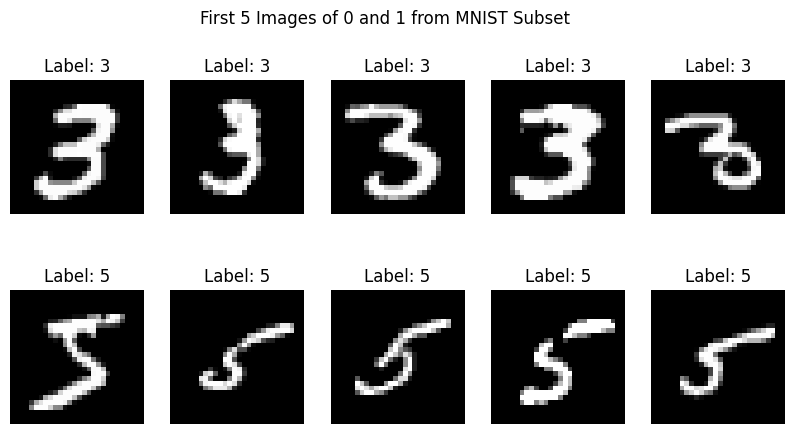

In [161]:
# Separate images for label 0 and label 1
images_0 = X[y == 3]  # Get all images with label 0
images_1 = X[y == 5]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

Each weight corresponds to one pixel in the image. It represents the importance of that pixel in deciding whether the image is a 0 or a 1.


*   High positive weight : that pixel strongly suggests the image is a 1
* High negative weight : that pixel strongly suggests the image is a 0
* Weight near zero : that pixel is not useful for classification



Why initialize weights to zero?\
it's a neutral starting point, making no assumptions about which pixels matter before training begins.

In [162]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [163]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

What is the purpose of the output = np.dot(X[i], weights) + bias line?\
It computes the weighted sum of all 784 pixels for one image

What happens when the prediction is wrong? How are the weights and bias updated?\
When the prediction is wrong there are two possible outcomes:


*   If the target value is 1 but predicts 0 then the weights and bias increase, pushing the linear output **w⋅x+b** upward so the neuron is more likely to fire (output 1) for similar inputs next time.
*   If the target value is 0 but predicts 1 then the weights and bias decrease, pulling the linear output downward so the neuron is less likely to fire for similar inputs.
*   If it predicts correctly no update at all. The weights stay frozen.



Why is the final accuracy important, and what do you expect it to be?\
The final accuracy is important because it tells how well the perceptron has learned to separate 0s and 1s

In [164]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for i in range(epochs):
      correct = 0
      for j in range(len(X)):
        linear_output = np.dot(X[j], weights) + bias
        y_pred = 5 if linear_output >= 0 else 3

        error = y[j] - y_pred
        weights += learning_rate * error * X[j]
        bias += learning_rate * error

        if error == 0:
          correct += 1
    accuracy = correct /len(X)


    return weights, bias, accuracy

## Training the Perceptron

In [165]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.9857716161984678


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.9869


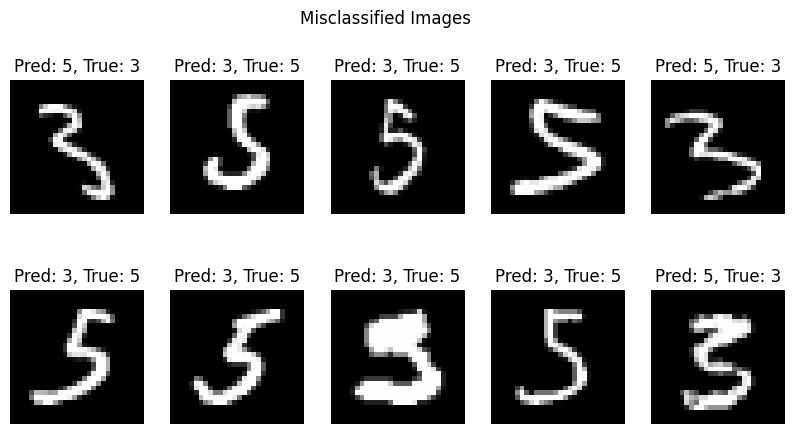

In [166]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")